In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def process_task_data(df, task):
    task_data = df[df['task'] == task]
    print(f"{task.capitalize()} data shape:", task_data.shape)
    return task_data

def create_plots(task_data, task, metric, save = False):
    metric_data = task_data[task_data['metric'] == metric]
    metric_data['value'] = metric_data['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    print(f"Data for {metric}:")
    print(metric_data.head(3))

    if metric_data.empty:
        print(f"Warning: No data found for metric '{metric}'")
        axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=12, fontweight='bold')

    # Create a new row for each config value
    unique_configs = metric_data['config'].unique()
    num_configs = len(unique_configs)
    fig.set_figheight(6 * num_configs)  # Adjust figure height based on number of configs

    for j, config in enumerate(unique_configs):
        config_data = metric_data[metric_data['config'] == config]
        ax = plt.subplot(num_configs, len(metrics), i + 1 + j * len(metrics))
        
        sns.barplot(data=config_data, x='finetune_algo', y='value', hue='type', ax=ax, order=['n/a', 'lora', 'full'])
        ax.set_title(f'{metric} - {config}')
        ax.set_xlabel('Finetune Algorithm')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=45)


        
        if i == len(metrics) - 1:  # Only add legend to the last subplot in each row
            ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            ax.legend().remove()

    
    

In [3]:
 
df = pd.read_csv('combined_metrics.csv')

# df = df[df['change'] == change]

# print("DataFrame shape:", df.shape)
# print("DataFrame columns:", df.columns)
# print("Unique values in 'Task' column:", df['task'].unique())
# print("Unique values in 'Metric' column:", df['metric'].unique())

# tasks = ['celebrity', 'art', 'object']

# plt.style.use('fivethirtyeight')


# for task in tasks:
#     task_data = process_task_data(df, task)
    
#     if task_data.empty:
#         print(f"Error: No data found for the '{task}' task.")
#         continue
#     create_plots(task_data, task)

Data for clip_acc:
   algo       change    task      config finetune_algo finetune_task  \
0  MACE  car_reg=0.0  object  erase_ship          lora        object   
1  MACE  car_reg=0.0  object  erase_ship          lora        object   
2  MACE  car_reg=0.0  object  erase_ship          lora        object   

               finetune_prompts           prompts_csv  seed      type  \
0  object_random_concepts_seed0  object_ship_concepts     0    erased   
1  object_random_concepts_seed0  object_ship_concepts     0    others   
2  object_random_concepts_seed0  object_ship_concepts     0  synonyms   

     metric     value  
0  clip_acc  0.085000  
1  clip_acc  0.999444  
2  clip_acc  0.153333  
(54, 12)


/tmp/ipykernel_3243316/4192824349.py:29: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)


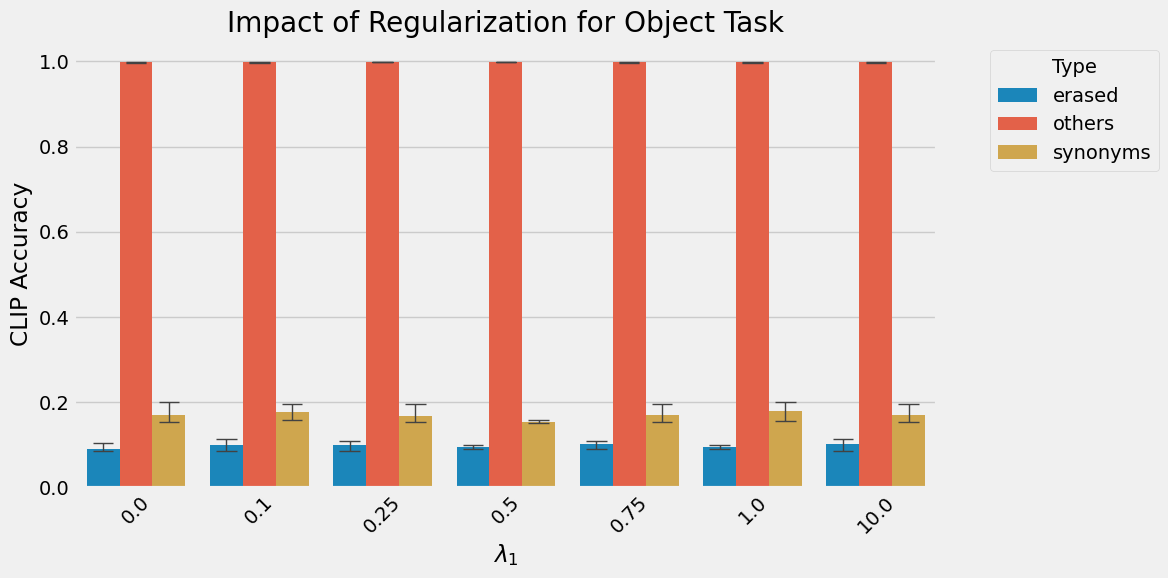

Figure saved as 'figures/regularization/object_regularization_impact.png'


In [4]:
change = 'regularization'
change_str = 'car_reg'
task = 'object'
metric = 'clip_acc'

plt.style.use('fivethirtyeight')

df_fig = df[df['change'].str.contains(change_str, na=False)]
df_fig = df_fig[df_fig['task'] == task]
df_fig = df_fig[df_fig['metric'] == metric]
#df_fig = df_fig[df_fig['type'] != 'others']
df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
print(f"Data for {metric}:")
print(df_fig.head(3))
print(df_fig.shape)

# Filter out 'full' type and keep only 'n/a' and 'lora'
df_fig = df_fig[df_fig['finetune_algo'].isin(['n/a', 'lora'])]

# Extract the numeric value from 'change' column and sort
df_fig['change_value'] = df_fig['change'].str.extract('(\d+(?:\.\d+)?)').astype(float)
df_fig = df_fig.sort_values('change_value')

# Create a single figure
fig, ax = plt.subplots(figsize=(12, 6))
#fig.suptitle(f'{task.capitalize()} Task', fontsize=16)

# Plot the data with sorted x-axis and smaller confidence interval bars
sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)

ax.set_title(f'Impact of Regularization for {task.capitalize()} Task')
ax.set_xlabel(r'$\lambda_1$')
ax.set_ylabel('CLIP Accuracy')
ax.tick_params(axis='x', rotation=45)

ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Create the 'figures/regularization' directory if it doesn't exist
import os
os.makedirs('figures/regularization', exist_ok=True)

# Save the figure
fig.savefig(f'figures/regularization/{task}_regularization_impact.png', dpi=300, bbox_inches='tight')
print(f"Figure saved as 'figures/regularization/{task}_regularization_impact.png'")


Data for GCD:
     algo    change       task        config finetune_algo finetune_task  \
148  MACE  baseline  celebrity  erase_cele_1          none          none   
149  MACE  baseline  celebrity  erase_cele_1          none          none   
150  MACE  baseline  celebrity  erase_cele_1          lora     celebrity   

                    finetune_prompts           prompts_csv  seed    type  \
148                             none  celebrity_1_concepts     1  erased   
149                             none  celebrity_1_concepts     1  others   
150  celebrity_random_concepts_seed0  celebrity_1_concepts     1  erased   

    metric     value  
148    GCD  0.000000  
149    GCD  0.926375  
150    GCD  0.012295  
(87, 12)


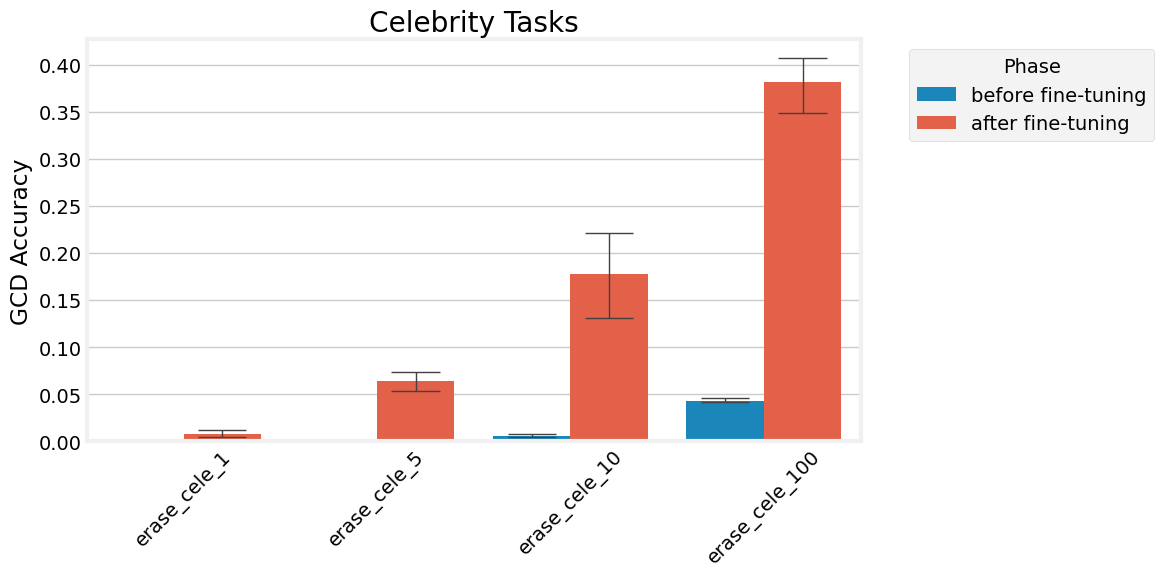

Figure saved as 'figures/warmup/celebrity_warmup_impact.png'


In [7]:
change = 'warmup'
change_str = 'baseline'
task = 'celebrity'

metric_map = {'object': 'clip_acc', 'art': 'clip_score', 'celebrity': 'GCD'}
metric_str = {'clip_acc': 'CLIP Accuracy', 'clip_score': 'CLIP Score', 'GCD': 'GCD Accuracy'}
metric = metric_map[task]

plt.style.use('fivethirtyeight')

df_fig = df[df['change'].str.contains(change_str, na=False)]
df_fig = df_fig[df_fig['task'] == task]
df_fig = df_fig[df_fig['metric'] == metric]
#df_fig = df_fig[df_fig['finetune_task'] == task]
#df_fig = df_fig[df_fig['type'] != 'others']
df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
print(f"Data for {metric}:")
print(df_fig.head(3))
print(df_fig.shape)

# Filter out 'full' type and keep only 'none' and 'lora'
df_fig = df_fig[df_fig['finetune_algo'].isin(['none', 'lora'])]


df_fig = df_fig[df_fig['type'].isin(['erased'])]
if task == 'celebrity':
    # Extract the number at the end of the config string
    df_fig['config_num'] = df_fig['config'].str.extract('(\d+)$').astype(int)

    # Sort the dataframe by this number
    df_fig = df_fig.sort_values('config_num')

    # Create a custom order for the x-axis based on the sorted config
    custom_order = df_fig['config'].unique()

    # Drop the temporary column
    df_fig = df_fig.drop('config_num', axis=1)


# Create a new 'phase' column based on 'finetune_algo'
df_fig['phase'] = df_fig['finetune_algo'].map({'none': 'before fine-tuning', 'lora': 'after fine-tuning'})

# Create a single figure
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('white')  # Set axes background to white

# Plot the data with sorted x-axis and smaller confidence interval bars
sns.barplot(data=df_fig, x='config', y='value', hue='phase', ax=ax, order=df_fig['config'].unique(), capsize=0.5, err_kws={'linewidth': 1})

ax.set_title(f'{task.capitalize()} Tasks')
ax.set_xlabel('')
#ax.set_xlabel('Task')
ax.set_ylabel(metric_str[metric])
ax.tick_params(axis='x', rotation=45)

ax.legend(title='Phase', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Create the 'figures/warmup' directory if it doesn't exist
import os
os.makedirs('figures/warmup', exist_ok=True)

# Save the figure
fig.savefig(f'figures/warmup/{task}_warmup_impact.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/warmup/{task}_warmup_impact.png'")


Data for clip_acc:
    algo    change    task      config finetune_algo finetune_task  \
82  MACE  baseline  object  erase_ship          none          none   
83  MACE  baseline  object  erase_ship          none          none   
84  MACE  baseline  object  erase_ship          none          none   

   finetune_prompts           prompts_csv  seed      type    metric     value  
82             none  object_ship_concepts     1    erased  clip_acc  0.105000  
83             none  object_ship_concepts     1    others  clip_acc  0.999444  
84             none  object_ship_concepts     1  synonyms  clip_acc  0.158333  
(102, 12)


/tmp/ipykernel_3243316/2794396247.py:30: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


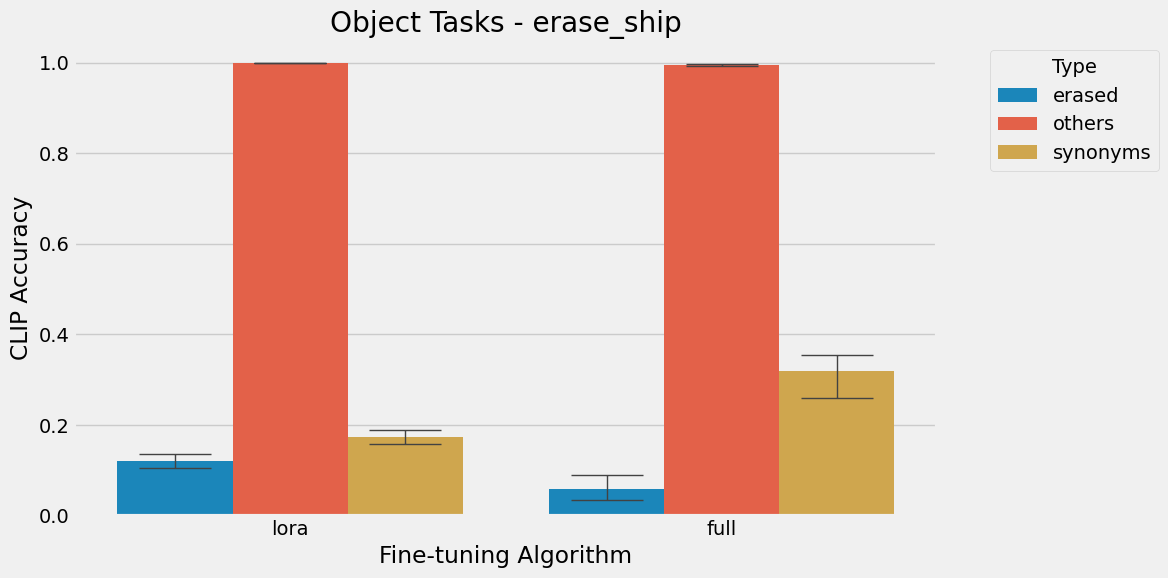

Figure saved as 'figures/finetuning/object_finetuning_comparison.png'


In [6]:
change = 'finetuning'
change_str = 'baseline'
task = 'object'

metric_map = {'object': 'clip_acc', 'art': 'clip_score', 'celebrity': 'GCD'}
metric_str = {'clip_acc': 'CLIP Accuracy', 'clip_score': 'CLIP Score', 'GCD': 'GCD Accuracy'}
metric = metric_map[task]

plt.style.use('fivethirtyeight')

df_fig = df[df['change'].str.contains(change_str, na=False)]
df_fig = df_fig[df_fig['task'] == task]
df_fig = df_fig[df_fig['metric'] == metric]
df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
print(f"Data for {metric}:")
print(df_fig.head(3))
print(df_fig.shape)

# Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
df_fig = df_fig[df_fig['finetune_algo'].isin(['full', 'lora'])]
df_fig = df_fig[df_fig['config'] == 'erase_ship']

# Include both 'erased' and 'others' types
#df_fig = df_fig[df_fig['type'].isin(['erased', 'others'])]

# Create a single figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the data with finetune_algo on x-axis and type as hue
sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

ax.set_title(f'{task.capitalize()} Tasks - {df_fig["config"].iloc[0]}')
ax.set_xlabel('Fine-tuning Algorithm')
ax.set_ylabel(metric_str[metric])
ax.tick_params(axis='x', rotation=0)

ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Create the 'figures/warmup' directory if it doesn't exist
import os
os.makedirs('figures/finetuning', exist_ok=True)

# Save the figure
fig.savefig(f'figures/finetuning/{task}_finetuning_comparison.png', dpi=300, bbox_inches='tight')
print(f"Figure saved as 'figures/finetuning/{task}_finetuning_comparison.png'")
